# Temperature forecast 2026 to 2030, based on anomalies

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

## ✅ 1️⃣ Load anomaly file

In [4]:
bi_anomaly_table = pd.read_csv(
    "../../../../data/clean/Yashaswi/Final_Clean/temperature_anomalies.csv",
    parse_dates=["Date"]
)

C:\Users\biauser\AppData\Local\Temp\ipykernel_1148\445004920.py:1: DtypeWarning: Columns (0: station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  bi_anomaly_table = pd.read_csv(


In [5]:
bi_anomaly_table.head(3)

,station_id,Date,Baseline Mean Temp (°C),Temp Anomaly (°C)
0,8204020,2021-09-11,16.54,-2.84
1,8204020,2021-09-12,15.80,0.30
2,8204020,2021-09-13,17.14,-1.24


## ✅ 2️⃣ Validate date coverage (critical check)

In [4]:
print(
    bi_anomaly_table["Date"].min(),
    bi_anomaly_table["Date"].max()
)

1995-01-01 00:00:00 2025-12-31 00:00:00


## Restrict TRAINING data to 2015–2025

In [5]:
train_df = bi_anomaly_table[
    (bi_anomaly_table["Date"] >= "2015-01-01") &
    (bi_anomaly_table["Date"] <= "2025-12-31")
].copy()

## ✅ 4️⃣ Daily regional mean (reduce station noise)
- We average anomalies across stations per day.

In [6]:
daily = (
    train_df
    .groupby("Date", as_index=False)
    .agg(
        Mean_Anomaly=("Temp Anomaly (°C)", "mean"),
        Mean_Baseline=("Baseline Mean Temp (°C)", "mean")
    )
)

## ✅ 5️⃣ Smooth daily anomalies (remove weather noise)

In [7]:
daily = daily.sort_values("Date")

daily["Anomaly_30d"] = (
    daily
    .set_index("Date")["Mean_Anomaly"]
    .rolling(30, center=True)
    .mean()
    .values
)

## ✅ 6️⃣ Create time index for regression

In [8]:
t0 = daily["Date"].min()

daily["time_days"] = (
    daily["Date"] - t0
).dt.days

## ✅ 7️⃣ Fit the trend model (transparent & explainable)

In [9]:
train = daily.dropna(subset=["Anomaly_30d"])

X = train[["time_days"]].values
y = train["Anomaly_30d"].values

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 🌡 Report this number
- ➡️ °C per year warming trend

In [10]:
warming_rate_per_year = model.coef_[0] * 365
warming_rate_per_year

np.float64(0.1599346201516747)

## ✅ 8️⃣ Create future DAILY dates (2026–2030)

In [11]:
future_dates = pd.date_range(
    start="2026-01-01",
    end="2030-12-31",
    freq="D"
)

future = pd.DataFrame({"Date": future_dates})

future["time_days"] = (
    future["Date"] - t0
).dt.days


✅ 9️⃣ Predict future anomalies

In [12]:
future["Predicted_Anomaly"] = model.predict(
    future[["time_days"]].values
)

## ✅ 🔟 Add uncertainty bounds (95%)

In [13]:
residuals = y - model.predict(X)
resid_std = np.std(residuals)

future["Lower_Anomaly"] = (
    future["Predicted_Anomaly"] - 1.96 * resid_std
)
future["Upper_Anomaly"] = (
    future["Predicted_Anomaly"] + 1.96 * resid_std
)

## ✅ 11️⃣ Reconstruct EXPECTED DAILY TEMPERATURE
- Build day‑of‑year baseline

In [14]:
baseline_doy = (
    daily
    .assign(
        Month=lambda d: d["Date"].dt.month,
        Day=lambda d: d["Date"].dt.day
    )
    .groupby(["Month", "Day"], as_index=False)
    .agg(
        Baseline=("Mean_Baseline", "mean")
    )
)

## Merge and reconstruct temperature

In [15]:
future["Month"] = future["Date"].dt.month
future["Day"] = future["Date"].dt.day

forecast = future.merge(
    baseline_doy,
    on=["Month", "Day"],
    how="left"
)

forecast["Expected_Temperature_C"] = (
    forecast["Baseline"] +
    forecast["Predicted_Anomaly"]
)

## ✅ 12️⃣ Final DAILY forecast table (BI‑ready)

In [16]:
forecast_daily = forecast[
    [
        "Date",
        "Expected_Temperature_C",
        "Predicted_Anomaly",
        "Lower_Anomaly",
        "Upper_Anomaly",
    ]
].round(3)

C:\Users\biauser\AppData\Local\Temp\ipykernel_11088\3427507946.py:9: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(3)


## ✅ Step 1: Build observed daily expected temperature (from anomalies)

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Restrict observed data
observed = bi_anomaly_table[
    (bi_anomaly_table["Date"] >= "2015-01-01") &
    (bi_anomaly_table["Date"] <= "2025-12-31")
].copy()

# Compute daily expected temperature = baseline + anomaly
observed["Expected_Temp"] = (
    observed["Baseline Mean Temp (°C)"] +
    observed["Temp Anomaly (°C)"]
)

# Regional daily mean (reduce station noise)
observed_daily = (
    observed
    .groupby("Date", as_index=False)
    .agg(Expected_Temperature_C=("Expected_Temp", "mean"))
)

## ✅ Step 2: Plot observed vs forecast (with uncertainty)

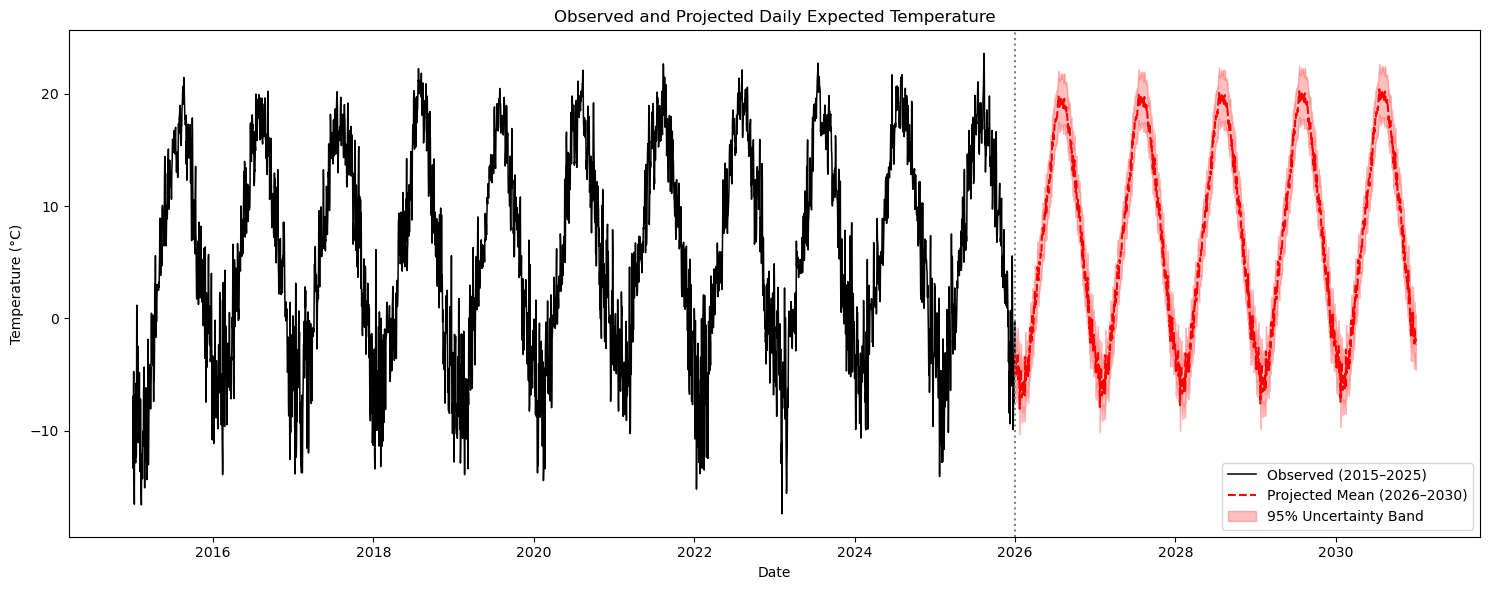

In [18]:
plt.figure(figsize=(15, 6))

# Observed
plt.plot(
    observed_daily["Date"],
    observed_daily["Expected_Temperature_C"],
    color="black",
    linewidth=1.1,
    label="Observed (2015–2025)"
)

# Forecast mean
plt.plot(
    forecast_daily["Date"],
    forecast_daily["Expected_Temperature_C"],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Projected Mean (2026–2030)"
)

# Uncertainty band (CORRECTED)
lower_temp = (
    forecast_daily["Expected_Temperature_C"]
    - (forecast_daily["Predicted_Anomaly"] - forecast_daily["Lower_Anomaly"])
)

upper_temp = (
    forecast_daily["Expected_Temperature_C"]
    + (forecast_daily["Upper_Anomaly"] - forecast_daily["Predicted_Anomaly"])
)

plt.fill_between(
    forecast_daily["Date"],
    lower_temp,
    upper_temp,
    color="red",
    alpha=0.25,
    label="95% Uncertainty Band"
)

plt.axvline(pd.Timestamp("2026-01-01"), color="gray", linestyle=":")

plt.title("Observed and Projected Daily Expected Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

## ✅ Step 1: Add Season column (meteorological)

In [19]:
def season_from_month(m):
    if m in [12, 1, 2]:
        return "Winter"
    if m in [3, 4, 5]:
        return "Spring"
    if m in [6, 7, 8]:
        return "Summer"
    return "Fall"

In [20]:
observed_daily["Season"] = observed_daily["Date"].dt.month.map(season_from_month)
forecast_daily["Season"] = forecast_daily["Date"].dt.month.map(season_from_month)

In [21]:
forecast_daily["Lower_Temp"] = (
    forecast_daily["Expected_Temperature_C"]
    - (forecast_daily["Predicted_Anomaly"] - forecast_daily["Lower_Anomaly"])
)

forecast_daily["Upper_Temp"] = (
    forecast_daily["Expected_Temperature_C"]
    + (forecast_daily["Upper_Anomaly"] - forecast_daily["Predicted_Anomaly"])
)


In [22]:
forecast_daily.columns

Index(['Date', 'Expected_Temperature_C', 'Predicted_Anomaly', 'Lower_Anomaly',
       'Upper_Anomaly', 'Season', 'Lower_Temp', 'Upper_Temp'],
      dtype='str')

## ✅ STEP 2 (MOST RECOMMENDED): Seasonal mean temperature trend

In [23]:
fc_seasonal = (
    forecast_daily
    .assign(Year=lambda d: d["Date"].dt.year,
            Season=forecast_daily["Season"])
    .groupby(["Year", "Season"], as_index=False)
    .agg(
        Temp=("Expected_Temperature_C", "mean"),
        Lower=("Lower_Temp", "mean"),
        Upper=("Upper_Temp", "mean"),
    )
)

In [24]:
obs_seasonal = (
    observed_daily
    .assign(Year=lambda d: d["Date"].dt.year)
    .groupby(["Year", "Season"], as_index=False)
    .agg(Temp=("Expected_Temperature_C", "mean"))
)

fc_seasonal = (
    forecast_daily
    .assign(Year=lambda d: d["Date"].dt.year)
    .groupby(["Year", "Season"], as_index=False)
    .agg(
        Temp=("Expected_Temperature_C", "mean"),
        Lower=("Lower_Temp", "mean"),
        Upper=("Upper_Temp", "mean"),
    )
)

## ✅ Plot: Season‑wise projected temperatures

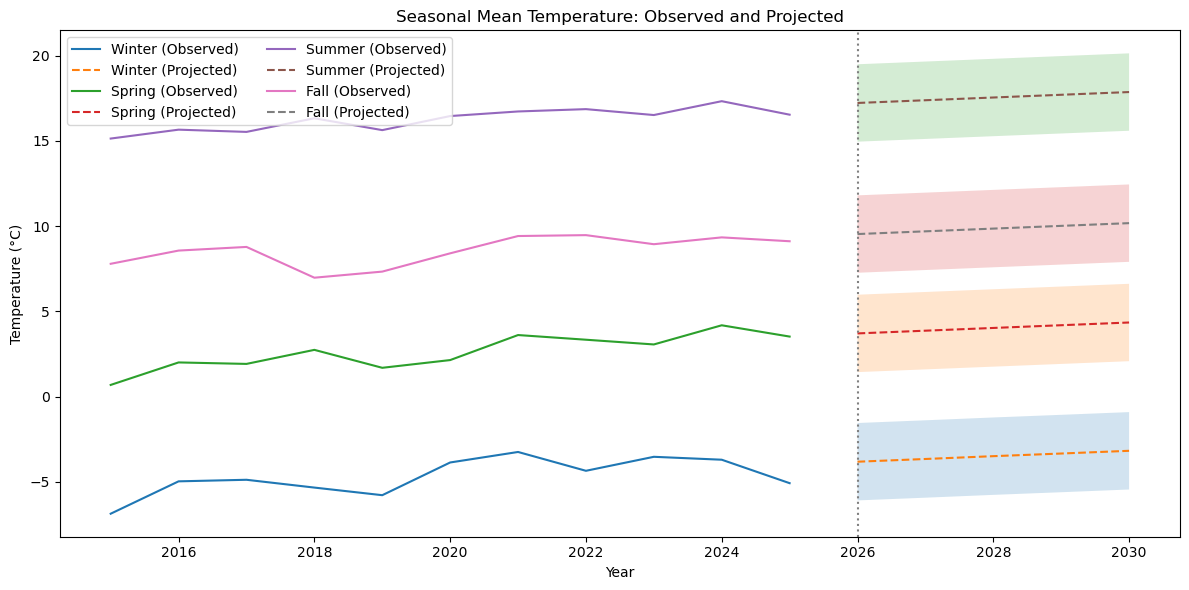

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for season in ["Winter", "Spring", "Summer", "Fall"]:
    obs = obs_seasonal[obs_seasonal["Season"] == season]
    fc  = fc_seasonal[fc_seasonal["Season"] == season]

    plt.plot(obs["Year"], obs["Temp"], label=f"{season} (Observed)")
    plt.plot(fc["Year"], fc["Temp"], linestyle="--", label=f"{season} (Projected)")
    plt.fill_between(fc["Year"], fc["Lower"], fc["Upper"], alpha=0.2)

plt.axvline(2026, color="gray", linestyle=":")
plt.title("Seasonal Mean Temperature: Observed and Projected")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

## ✅ STEP 3: Individual seasonal panels (very clean)

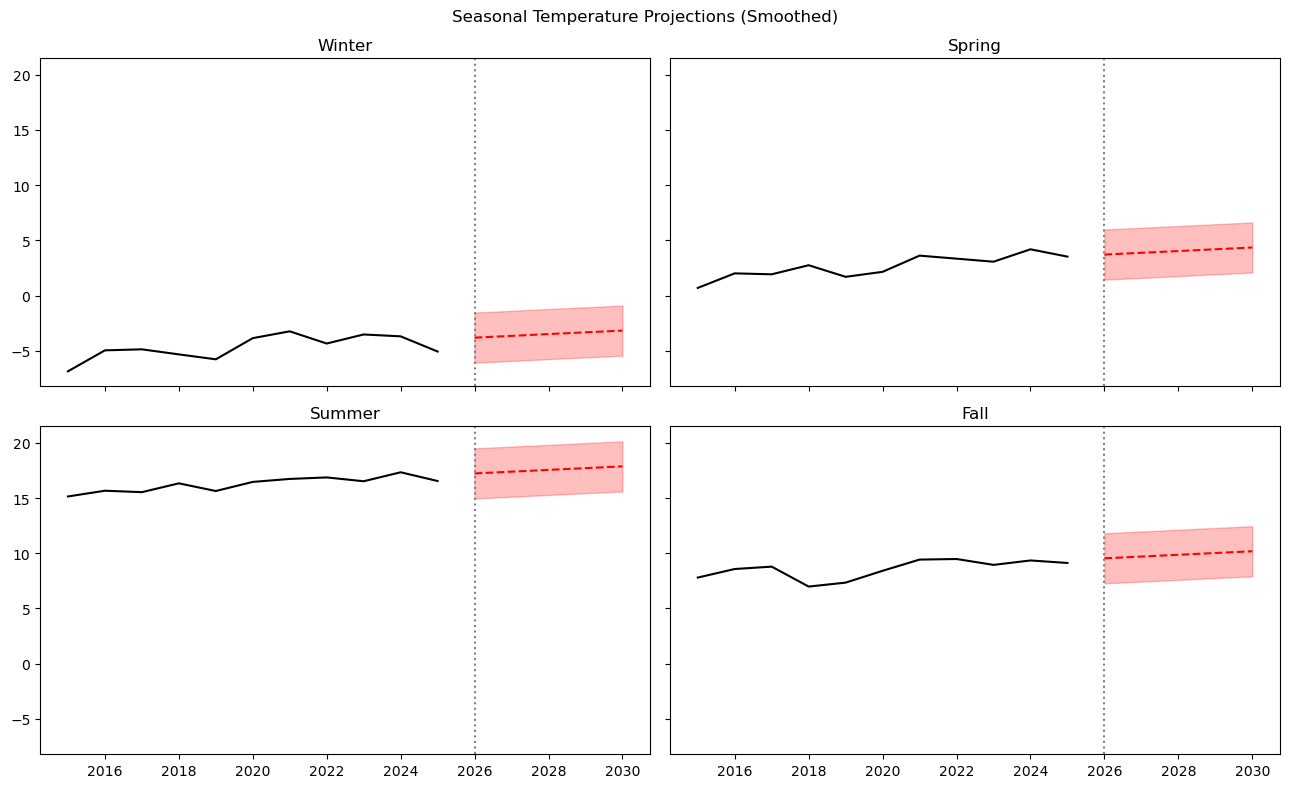

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)

season_axes = dict(
    zip(["Winter", "Spring", "Summer", "Fall"], axes.flatten())
)

for season, ax in season_axes.items():
    obs = obs_seasonal[obs_seasonal["Season"] == season]
    fc  = fc_seasonal[fc_seasonal["Season"] == season]

    ax.plot(obs["Year"], obs["Temp"], color="black")
    ax.plot(fc["Year"], fc["Temp"], color="red", linestyle="--")
    ax.fill_between(fc["Year"], fc["Lower"], fc["Upper"], color="red", alpha=0.25)

    ax.set_title(season)
    ax.axvline(2026, color="gray", linestyle=":")

fig.suptitle("Seasonal Temperature Projections (Smoothed)")
fig.tight_layout()
plt.show()

In [27]:

forecast_daily.head()


,Date,Expected_Temperature_C,Predicted_Anomaly,Lower_Anomaly,Upper_Anomaly,Season,Lower_Temp,Upper_Temp
0,2026-01-01,-3.044,0.923,-1.347,3.193,Winter,-5.314,-0.774
1,2026-01-02,-3.756,0.923,-1.346,3.193,Winter,-6.025,-1.486
2,2026-01-03,-4.984,0.924,-1.346,3.194,Winter,-7.254,-2.714
3,2026-01-04,-4.096,0.924,-1.346,3.194,Winter,-6.366,-1.826
4,2026-01-05,-3.699,0.925,-1.345,3.195,Winter,-5.969,-1.429


In [28]:
forecast_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    1826 non-null   datetime64[us]
 1   Expected_Temperature_C  1826 non-null   float64       
 2   Predicted_Anomaly       1826 non-null   float64       
 3   Lower_Anomaly           1826 non-null   float64       
 4   Upper_Anomaly           1826 non-null   float64       
 5   Season                  1826 non-null   str           
 6   Lower_Temp              1826 non-null   float64       
 7   Upper_Temp              1826 non-null   float64       
dtypes: datetime64[us](1), float64(6), str(1)
memory usage: 124.1 KB


In [29]:
forecast_daily.to_csv(
    r"../../../data/clean/Yashaswi/Final_Clean/daily_temperature_forecast_2026_2030.csv",
    index=False
)